Archivo cargado exitosamente en Colab


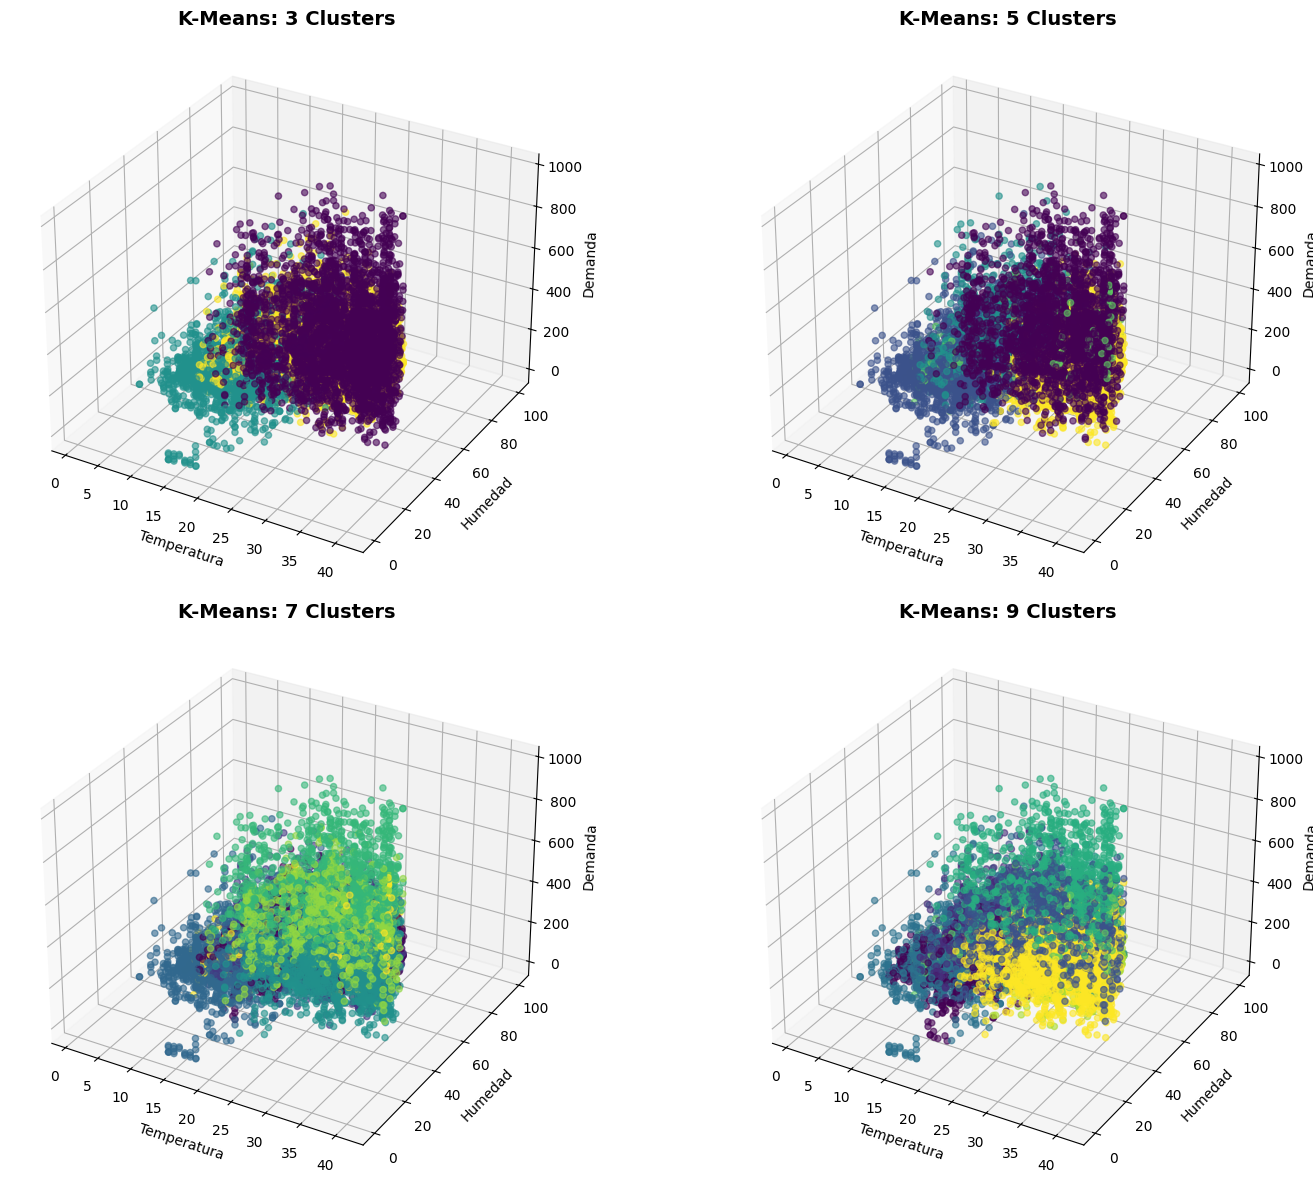

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

try:
    df = pd.read_csv('train.csv')
    print("Archivo cargado exitosamente en Colab")
except:
    print("Error: Asegúrate de haber subido 'train.csv' al panel de la izquierda.")

df['datetime'] = pd.to_datetime(df['datetime'])
df['hora'] = df['datetime'].dt.hour
df['mes'] = df['datetime'].dt.month
df['dia_semana'] = df['datetime'].dt.dayofweek

X = df.drop(['datetime'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

valores_k = [3, 5, 7, 9]
fig = plt.figure(figsize=(16, 12))

x_data = df['temp']
y_data = df['humidity']
z_data = df['count']

for i, k in enumerate(valores_k, 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    ax = fig.add_subplot(2, 2, i, projection='3d')
    scatter = ax.scatter(x_data, y_data, z_data, c=clusters, cmap='viridis', s=20, alpha=0.6)

    ax.set_title(f'K-Means: {k} Clusters', fontsize=14, fontweight='bold')
    ax.set_xlabel('Temperatura')
    ax.set_ylabel('Humedad')
    ax.set_zlabel('Demanda')

plt.tight_layout()
plt.show()